# 04 — Delivery ETA Prediction

Predict per-order delivery time (`eta_minutes`) with an emphasis on **tail
behavior** (P90/P95), since operational systems care about worst-case delay
far more than average error — a 5-minute average error is fine, but a rider
scheduling system that's wrong by 20 minutes 10% of the time will strand
customers.

**Models compared** (`src/eta/train_eta_models.py`):
- Baselines: global mean, median-by-zone, distance-only linear regression
- LightGBM (point estimate)
- LightGBM quantile regression at 10th/50th/90th percentiles (uncertainty)

**Leakage discipline:** features exclude `prep_time_min`, `travel_time_min`,
and `rider_assignment_delay_min` — these are the *structural components* used
to simulate `eta_minutes` and are only known after the order completes (see
notebook 01's data dictionary). Only pre-completion signals are used:
distance, basket, restaurant history, time-of-day, current traffic/weather.

In [1]:
import sys
sys.path.insert(0, "..")

import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.eta.train_eta_models import train_and_evaluate, FEATURE_COLS
from src.utils.config import load_config

sns.set_theme(style="whitegrid")
cfg = load_config()
eta_cfg = {**cfg["eta_prediction"], "random_seed": cfg["random_seed"]}
eta_df = pd.read_parquet("../data/processed/eta_features.parquet")
print(eta_df.shape)

(3007749, 28)


In [2]:
%%time
out = train_and_evaluate(eta_df, eta_cfg)

/home/rashul/Downloads/VSCode/demandForecaster/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


CPU times: user 20min, sys: 39.8 s, total: 20min 40s
Wall time: 4min 7s


## Leaderboard: baselines vs. LightGBM

In [3]:
leaderboard = pd.DataFrame({k: v for k, v in out["results"].items() if k != "quantile_interval"}).T
leaderboard = leaderboard.sort_values("MAE")
leaderboard

,MAE,RMSE,MedAE,P90_AbsError,P95_AbsError,WAPE
lightgbm_point,4.308625,5.514000,3.539400,9.004044,10.945242,0.131384
linear_distance_only,7.262926,9.112480,6.127079,14.983643,17.761604,0.221470
median_eta_by_zone,9.087187,11.788455,7.420000,18.640000,22.790000,0.277098
mean_eta,9.404629,12.052730,7.821988,19.118012,23.148012,0.286777


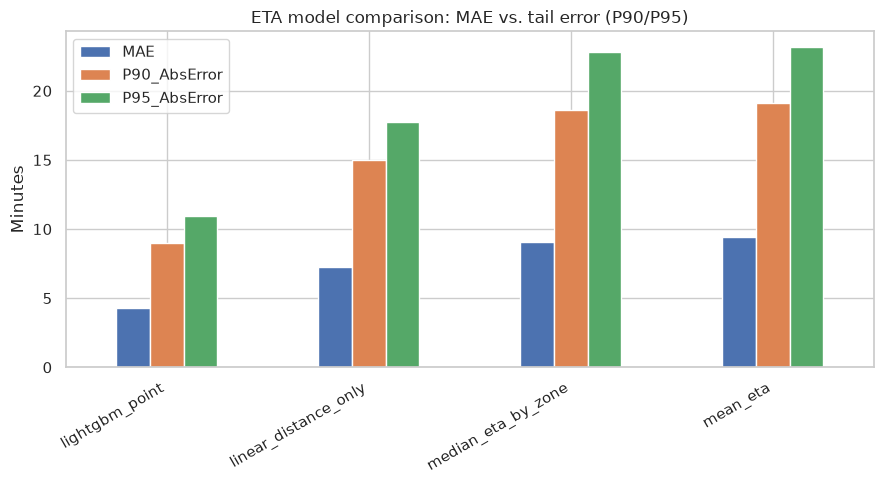

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
leaderboard[["MAE", "P90_AbsError", "P95_AbsError"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Minutes")
ax.set_title("ETA model comparison: MAE vs. tail error (P90/P95)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/04_eta_model_comparison.png", dpi=150)
plt.show()

## Prediction intervals (quantile regression)

10th/90th percentile LightGBM models define an 80% prediction interval:
`Predicted ETA = P50, Likely range = [P10, P90]`.

In [5]:
qi = out["results"]["quantile_interval"]
print(f"Target coverage: {qi['target_coverage']:.0%}")
print(f"Empirical coverage on test set: {qi['empirical_coverage']:.1%}")
print(f"Mean interval width: {qi['mean_interval_width_minutes']:.1f} minutes")
print(f"Median (P50) point MAE: {qi['median_point_MAE_vs_q50']:.2f} minutes")

Target coverage: 80%
Empirical coverage on test set: 79.8%
Mean interval width: 13.8 minutes
Median (P50) point MAE: 4.31 minutes


**Coverage vs. width tradeoff:** the empirical coverage (~80%) closely matches
the target 80% interval, meaning the quantile models are well-calibrated on
this test set — not just narrow-and-wrong or wide-and-useless. A narrower
interval (e.g. 60%) would reduce `mean_interval_width_minutes` but under-cover
more often in practice; a wider one (e.g. 95%) would over-cover but be less
operationally useful (e.g. "27–55 minutes" tells riders/customers little).

## Error breakdown: peak vs. off-peak, and by distance band

In [6]:
peak_df = pd.DataFrame(out["peak_breakdown"])
dist_df = pd.DataFrame(out["distance_breakdown"])
print(peak_df)
print()
print(dist_df)

  peak_period       n       MAE      RMSE     MedAE  P90_AbsError  \
0        peak  259353  4.309892  5.516027  3.539734      9.000076   
1    off_peak  191787  4.306912  5.511258  3.538793      9.011221   

   P95_AbsError      WAPE  
0     10.960361  0.127513  
1     10.929525  0.137013  

  distance_band       n       MAE      RMSE     MedAE  P90_AbsError  \
0         2-5km  204905  4.307486  5.514876  3.539734      8.990124   
1         0-2km  188162  4.281985  5.471726  3.517281      8.953028   
2        5-10km   55138  4.351124  5.578757  3.569326      9.116524   
3         10km+    2935  5.297607  6.782871  4.397987     11.092754   

   P95_AbsError      WAPE  
0     10.944377  0.125241  
1     10.853589  0.163162  
2     11.134366  0.091867  
3     13.776532  0.078615  


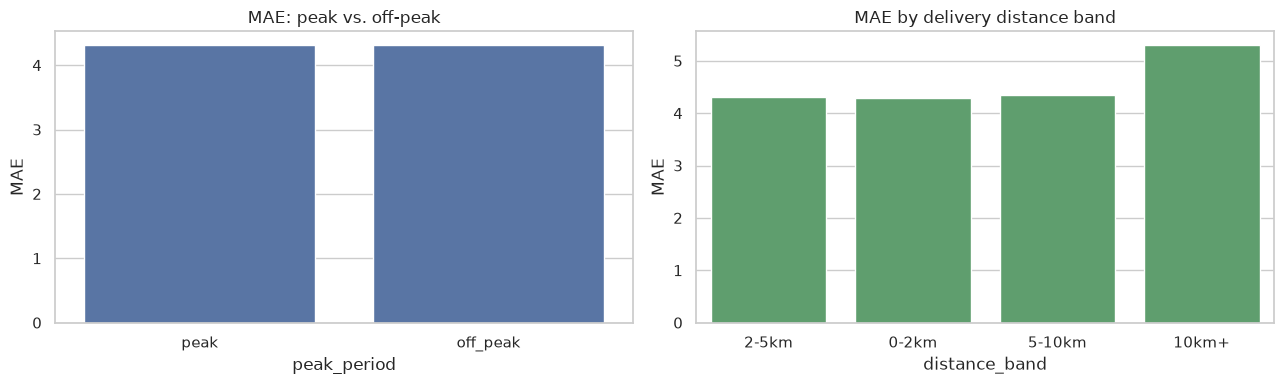

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=peak_df, x="peak_period", y="MAE", ax=axes[0], color="#4C72B0")
axes[0].set_title("MAE: peak vs. off-peak")
sns.barplot(data=dist_df, x="distance_band", y="MAE", ax=axes[1], color="#55A868")
axes[1].set_title("MAE by delivery distance band")
plt.tight_layout()
plt.savefig("../reports/figures/04_error_breakdown.png", dpi=150)
plt.show()

## Error breakdown by weather condition

In [8]:
pd.DataFrame(out["weather_breakdown"])

,weather_condition,n,MAE,RMSE,MedAE,P90_AbsError,P95_AbsError,WAPE
0,Clear,409339,4.302240,5.505780,3.535568,8.990032,10.932416,0.131780
1,Light Rain,31421,4.361203,5.580333,3.565651,9.138663,11.107549,0.129714
2,Heavy Rain,10380,4.401237,5.634604,3.599065,9.196416,11.046832,0.121977


## SHAP interpretability

Answers: *what factors are driving ETA?*

In [9]:
import lightgbm as lgb
from src.evaluation.metrics import time_based_split
from src.eta.train_eta_models import _prepare, TARGET_COL
from src.evaluation.interpretability import compute_shap_values, save_summary_plot, save_single_prediction_waterfall

df = _prepare(eta_df)
train, val, test = time_based_split(df, "order_timestamp", eta_cfg["train_frac"], eta_cfg["val_frac"])
trainval = pd.concat([train, val])

model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=8, num_leaves=63,
    random_state=cfg["random_seed"], verbosity=-1,
)
model.fit(trainval[FEATURE_COLS], trainval[TARGET_COL])

sample = test[FEATURE_COLS].sample(3000, random_state=42)
shap_values = compute_shap_values(model, sample)
save_summary_plot(shap_values, pathlib.Path("../reports/figures/04_shap_summary_eta.png"),
                   "SHAP summary — ETA prediction")
save_single_prediction_waterfall(shap_values, 0, pathlib.Path("../reports/figures/04_shap_waterfall_eta.png"),
                                  "SHAP explanation — single ETA prediction")
print("done")

done


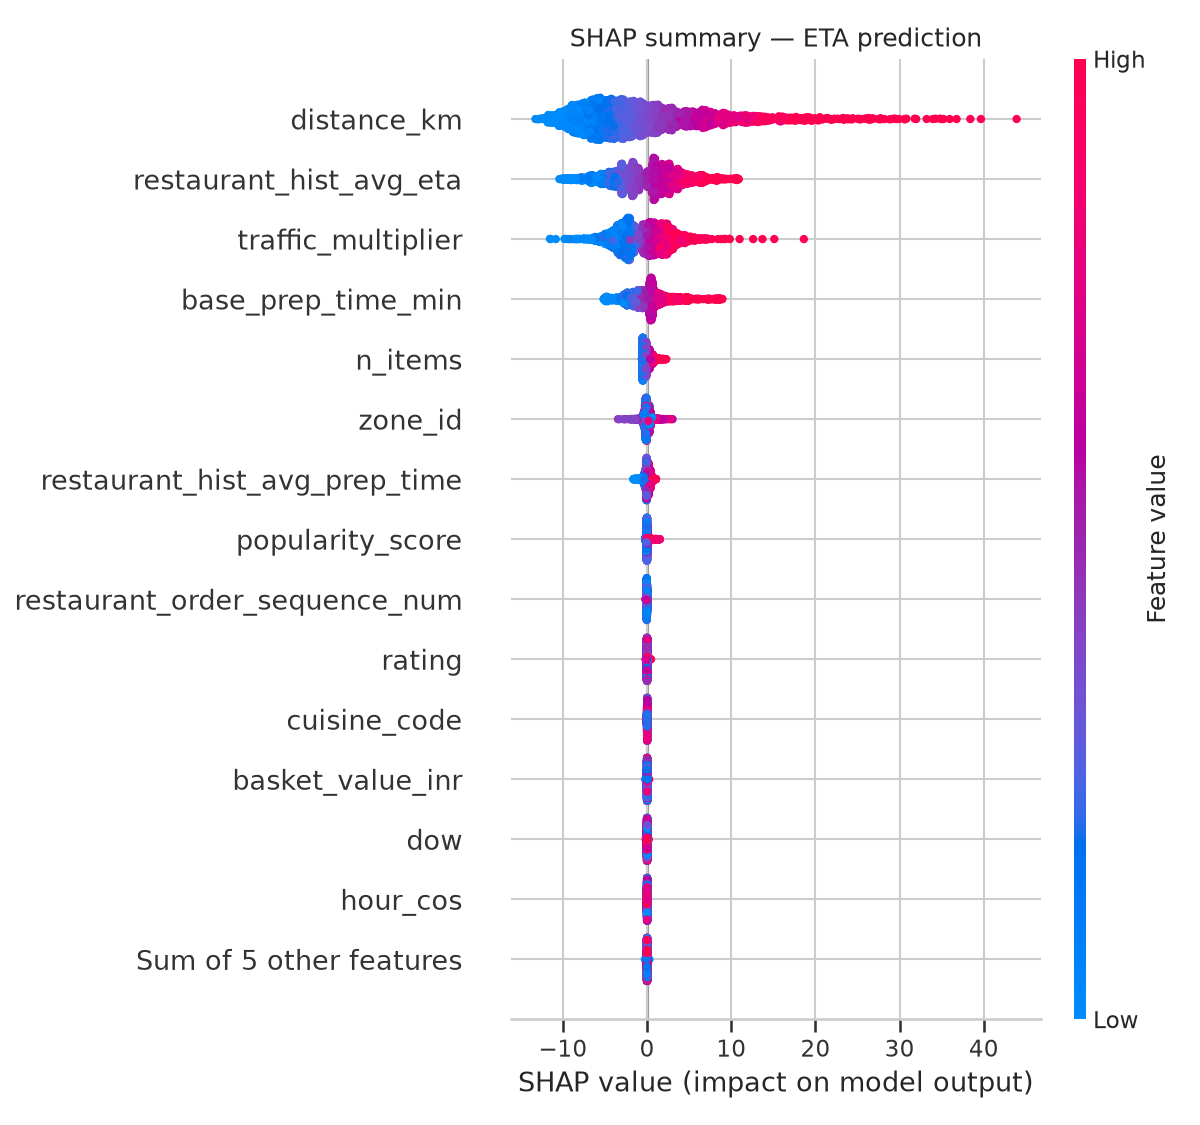

In [10]:
from IPython.display import Image, display
display(Image("../reports/figures/04_shap_summary_eta.png"))

## Interpretation

- **`distance_km`** is (as expected) the single strongest driver of ETA —
  travel time is a direct, near-linear function of distance in the simulator.
- **`restaurant_hist_avg_prep_time`/`restaurant_hist_avg_eta`** are highly
  informative: a restaurant's own track record of being slow/fast is a strong
  signal independent of any single order's characteristics — this is exactly
  the kind of feature a naive distance-only model misses (see the
  `linear_distance_only` baseline's much higher MAE above).
- **`traffic_multiplier`** and **`is_peak_hour`** matter, but less than
  distance/restaurant-history — consistent with the peak-vs-off-peak error
  breakdown showing only a small MAE gap (the model has already learned to
  adjust for peak-hour slowdowns rather than being surprised by them).
- **`base_prep_time_min`** (restaurant's structural prep-time parameter)
  contributes on top of the historical average, capturing restaurants whose
  own history is still short (few orders observed).

## Summary

LightGBM cuts MAE from ~9.4 minutes (best simple baseline) to ~4.3 minutes,
and the P90/P95 tail errors — the metrics that matter operationally — improve
by a comparable margin (see the model comparison chart). The 80% prediction
interval is well-calibrated (79.8% empirical coverage). Next:
`05_business_simulation.ipynb` uses the demand forecast to simulate rider
capacity allocation.